# LAHIS — Language Attention Head Importance Scores
### OLMo-2-7B × TED Multilingual Data

This notebook applies the LAHIS method to **OLMo-2-7B**.

**Steps:**
1. Install dependencies
2. Imports and setup
3. Config — language list aligned with Jonny's finetuning languages
4. Prepare TED data
5. Load OLMo-2-7B with custom LAHIS head-mask patch
6. Compute importance matrices (base model)
7. Heatmaps
8. Head distribution by layer
9. Language-specific vs language-general heads
10. Specificity validation — dark diagonal
11. Base vs finetuned comparison (run after Jonny uploads to HuggingFace)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!git clone -b eleftheria-lahis-analysis --single-branch https://github.com/jvonrad/Lost-in-Mistranslation.git

Cloning into 'Lost-in-Mistranslation'...
remote: Enumerating objects: 167, done.
remote: Counting objects: 100% (167/167), done.
remote: Compressing objects: 100% (106/106), done.
remote: Total 167 (delta 54), reused 167 (delta 54), pack-reused 0 (from 0)
Receiving objects: 100% (167/167), 2.89 MiB | 7.87 MiB/s, done.
Resolving deltas: 100% (54/54), done.


In [4]:
## 1 · Install dependencies
import subprocess, sys
pkgs = ["datasets", "transformers", "torch", "tqdm", "matplotlib", "huggingface_hub", "python-dotenv"]
subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + pkgs)

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'datasets', 'transformers', 'torch', 'tqdm', 'matplotlib', 'huggingface_hub', 'python-dotenv'], returncode=0)

In [6]:
## 2 · Imports and setup
import os, sys, json, gc, torch
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from IPython.display import display, Image
from tqdm.notebook import tqdm as tqdm_nb

# Navigate to LAHIS/src/ regardless of where the kernel started
cwd = os.path.abspath('')
if os.path.basename(cwd) == 'Lost-in-Mistranslation/src':
    SRC_DIR = cwd
elif os.path.isdir(os.path.join(cwd, 'Lost-in-Mistranslation/src')):
    SRC_DIR = os.path.join(cwd, 'Lost-in-Mistranslation/src')
else:
    raise FileNotFoundError(f"Cannot find src/ from {cwd} — open the notebook from LAHIS/")

os.chdir(SRC_DIR)
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

print('Working directory:', os.getcwd())
print('Python         :', sys.version.split()[0])
print('PyTorch        :', torch.__version__)
print('MPS available  :', torch.backends.mps.is_available())
print('CUDA available :', torch.cuda.is_available())

Working directory: /content/Lost-in-Mistranslation/src
Python         : 3.12.13
PyTorch        : 2.10.0+cu128
MPS available  : False
CUDA available : True


In [7]:
## 3 · Config

QUICK_TEST = False   # flip to True for a quick sanity check

# ── Device ────────────────────────────────────────────────────────────────────
if torch.backends.mps.is_available():
    DEVICE = 'mps'
elif torch.cuda.is_available():
    DEVICE = 'cuda'
else:
    DEVICE = 'cpu'
print('Using device:', DEVICE)

LANGUAGES = ["en", "de", "id", "pt", "ar", "bn", "sw", "es", "ru", "fr", "ja", "zh"]

if QUICK_TEST:
    DATA_NUM      = 10
    MAX_LENGTH    = 64
    SPEC_DATA_NUM = 10
else:
    DATA_NUM      = 1000
    MAX_LENGTH    = 512
    SPEC_DATA_NUM = 500

# UPDATED: Pointing to your mounted Google Drive
TED_JSONL = '/content/drive/MyDrive/UCL/SNLP/Ted_Data/multi_way.jsonl'
DATA_DIR  = '../data/ted'

if QUICK_TEST:
    RESULTS_DIR = '../results/olmo2_quicktest'
    HEATMAP_DIR = '../results/olmo2_quicktest/heatmaps'
else:
    RESULTS_DIR = '../results/olmo2'
    HEATMAP_DIR = '../results/olmo2/heatmaps'

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(HEATMAP_DIR, exist_ok=True)

TOP_P = 0.02

print(f'QUICK_TEST    : {QUICK_TEST}')
print(f'DATA_NUM      : {DATA_NUM}')
print(f'MAX_LENGTH    : {MAX_LENGTH}')
print(f'SPEC_DATA_NUM : {SPEC_DATA_NUM}')
print(f'Results dir   : {RESULTS_DIR}')

Using device: cuda
QUICK_TEST    : False
DATA_NUM      : 1000
MAX_LENGTH    : 512
SPEC_DATA_NUM : 500
Results dir   : ../results/olmo2


## 4 · Prepare TED Data
Converts the raw `multi_way.jsonl` into one JSON file per language.  
Each file is a list of `{"text": "..."}` chunks (5 sentences joined together).

**Notes on Jonny's language list:**
- `en, de, ar, es, ru, fr, ja, zh` → already built if you ran the Llama-2 notebook
- `id` (Indonesian), `pt` (Portuguese) → moderate resource, should have good TED coverage
- `bn` (Bengali), `sw` (Swahili) → low-resource; if < 1000 chunks exist the importance matrix will just use however many are available

**Skip this cell if all JSON files already exist.**

In [8]:
import ted_loader as TED

missing = [l for l in LANGUAGES if not os.path.exists(os.path.join(DATA_DIR, f'ted_{l}.json'))]

if not missing:
    print('All TED data files already exist — skipping.')
else:
    print(f'Building data for: {missing}')
    records = TED.load_ted_jsonl(TED_JSONL)
    print(f'Loaded {len(records):,} TED records')
    streams = TED.build_monolingual_streams(records, missing, join_n_sentences=5)
    TED.save_monolingual_json(streams, DATA_DIR)
    print('Done.')

# Show summary — mark missing ones
print('\nData files:')
AVAILABLE_LANGS = []
for lang in LANGUAGES:
    path = os.path.join(DATA_DIR, f'ted_{lang}.json')
    if os.path.exists(path):
        size = os.path.getsize(path) // (1024 * 1024)
        print(f'  {lang:6s}  {size:4d} MB')
        AVAILABLE_LANGS.append(lang)
    else:
        print(f'  {lang:6s}  MISSING — excluded from analysis')

print(f'\nWill run LAHIS on: {AVAILABLE_LANGS}')

Building data for: ['en', 'de', 'id', 'pt', 'ar', 'bn', 'sw', 'es', 'ru', 'fr', 'ja', 'zh']
Loaded 2,218,563 TED records
  [ar      ] 235,033 chunks  ->  ../data/ted/ted_ar.json
  [bn      ]  5,180 chunks  ->  ../data/ted/ted_bn.json
  [de      ] 116,063 chunks  ->  ../data/ted/ted_de.json
  [en      ] 319,515 chunks  ->  ../data/ted/ted_en.json
  [es      ] 250,755 chunks  ->  ../data/ted/ted_es.json
  [fr      ] 207,182 chunks  ->  ../data/ted/ted_fr.json
  [id      ] 90,731 chunks  ->  ../data/ted/ted_id.json
  [ja      ] 63,095 chunks  ->  ../data/ted/ted_ja.json
  [pt      ] 279,528 chunks  ->  ../data/ted/ted_pt.json
  [ru      ] 176,069 chunks  ->  ../data/ted/ted_ru.json
  [sw      ]  3,861 chunks  ->  ../data/ted/ted_sw.json
  [zh      ] 39,241 chunks  ->  ../data/ted/ted_zh.json
Done.

Data files:
  en        78 MB
  de        29 MB
  id        22 MB
  pt        70 MB
  ar        86 MB
  bn         3 MB
  sw         0 MB
  es        63 MB
  ru        71 MB
  fr        54 MB
 

## 5 · Load OLMo-2-7B
Downloads from HuggingFace on first run (~14 GB, open weights — **no token needed**).  
The custom OLMo-2 LAHIS patch is applied automatically. It is identical to the Llama-2 patch but adds `q_norm` / `k_norm` (RMSNorm applied per-head to queries and keys — OLMo-2 specific).

In [9]:
import importlib
import model_handler
importlib.reload(model_handler)

model, tokenizer = model_handler.load_model(
    'olmo2',
    device=DEVICE,
    half_precision=True,   # bfloat16 → ~14 GB
    local=False,
)
model.eval()

NUM_LAYERS = model.config.num_hidden_layers   # 32
NUM_HEADS  = model.config.num_attention_heads  # 32
print(f'\nModel : OLMo-2-7B')
print(f'Layers: {NUM_LAYERS}  ×  Heads: {NUM_HEADS}  =  {NUM_LAYERS * NUM_HEADS} total heads')
print('LAHIS patch applied:', hasattr(model.model.layers[0].self_attn, '_lahis_mask'))

config.json:   0%|          | 0.00/623 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Load model in torch.bfloat16


...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/355 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/126 [00:00<?, ?B/s]

Applying LAHIS head-mask patch to OLMo-2 attention layers...
  Patch applied.
** Memory allocated by model: 13.59 GB


Model : OLMo-2-7B
Layers: 32  ×  Heads: 32  =  1024 total heads
LAHIS patch applied: True


## 6 · Compute LAHIS Importance Matrices (Base Model)
For each language, run a forward+backward pass over TED text samples.  
The gradient of the soft head mask gives the importance of each head for that language.

**Output:** `../results/olmo2/olmo2_{lang}.pth` — a `[32 × 32]` tensor per language.  
**Cached:** if the `.pth` file already exists the matrix is loaded instead of recomputed.

In [10]:
from attn_matrix_ted import get_attn_head_matrix_ted

importance_matrices = {}

for lang in AVAILABLE_LANGS:
    out_path = os.path.join(RESULTS_DIR, f'olmo2_{lang}.pth')

    if os.path.exists(out_path):
        print(f'[{lang}] Loading cached matrix')
        importance_matrices[lang] = torch.load(out_path, map_location='cpu').float()
        m = importance_matrices[lang]
        print(f'      Score range: [{m.min():.2f}, {m.max():.2f}]')
    else:
        print(f'\n[{lang}] Computing importance matrix ({DATA_NUM} samples)...')
        matrix = get_attn_head_matrix_ted(
            model, tokenizer,
            lan=lang,
            model_name='olmo2',
            data_dir=DATA_DIR,
            data_num=DATA_NUM,
            max_length=MAX_LENGTH,
        )
        importance_matrices[lang] = matrix.float()
        torch.save(matrix, out_path)
        print(f'      Saved → {out_path}')

print(f'\nMatrices ready for: {list(importance_matrices.keys())}')

[en] Loading cached matrix
      Score range: [0.00, 127.20]
[de] Loading cached matrix
      Score range: [0.00, 193.86]
[id] Loading cached matrix
      Score range: [0.00, 267.87]
[pt] Loading cached matrix
      Score range: [0.00, 523.20]
[ar] Loading cached matrix
      Score range: [0.00, 112.81]
[bn] Loading cached matrix
      Score range: [0.00, 177.15]
[sw] Loading cached matrix
      Score range: [0.00, 837.61]
[es] Loading cached matrix
      Score range: [0.00, 612.85]
[ru] Loading cached matrix
      Score range: [0.00, 108.27]
[fr] Loading cached matrix
      Score range: [0.00, 651.81]
[ja] Loading cached matrix
      Score range: [0.00, 134.12]
[zh] Loading cached matrix
      Score range: [0.00, 97.79]

Matrices ready for: ['en', 'de', 'id', 'pt', 'ar', 'bn', 'sw', 'es', 'ru', 'fr', 'ja', 'zh']


## 7 · Heatmaps
Each cell in the grid is one attention head. Brighter = more important for that language.  
Compare with the Llama-2 heatmaps to see whether OLMo-2 (more English-dominant) shows weaker or differently located language-specific patterns.

Saved → ../results/olmo2/heatmaps/all_languages_base.png


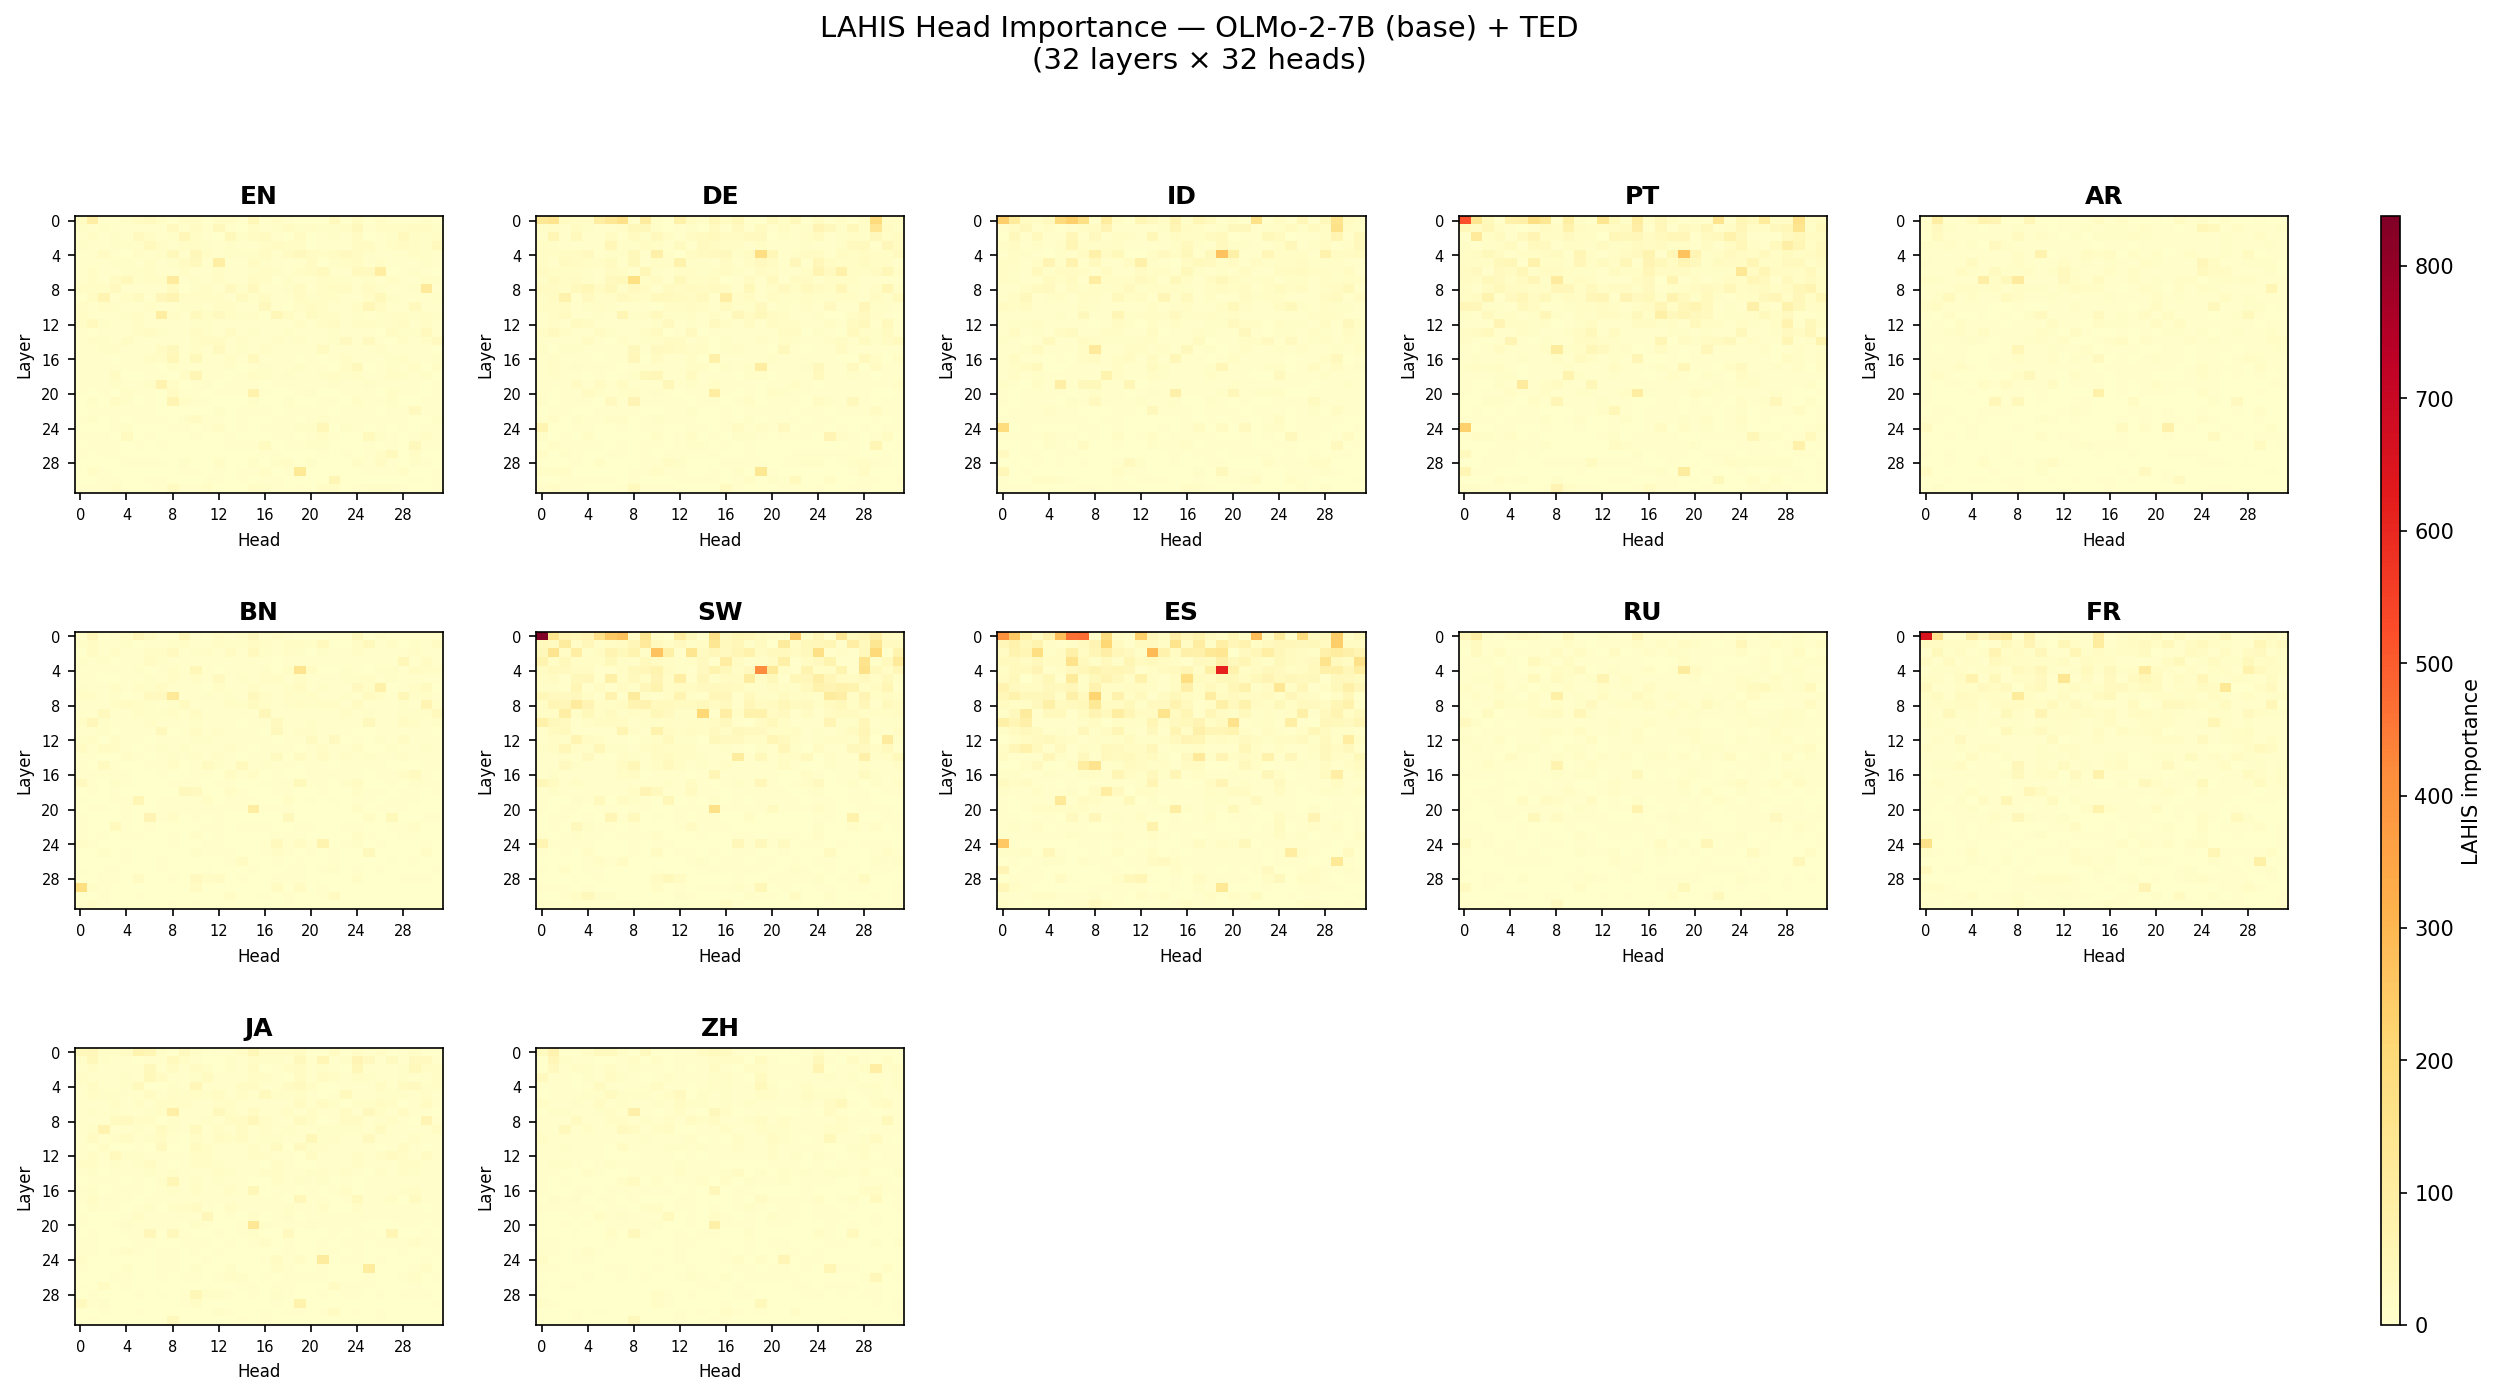

In [11]:
langs = list(importance_matrices.keys())
n     = len(langs)
ncols = min(n, 5)
nrows = (n + ncols - 1) // ncols

all_vals = torch.cat([importance_matrices[l].view(-1) for l in langs])
vmin, vmax = all_vals.min().item(), all_vals.max().item()

fig = plt.figure(figsize=(ncols * 4, nrows * 3.2))
gs  = gridspec.GridSpec(nrows, ncols + 1,
                        width_ratios=[1]*ncols + [0.05],
                        hspace=0.5, wspace=0.3)
last_im = None

for i, lang in enumerate(langs):
    row, col = divmod(i, ncols)
    ax  = fig.add_subplot(gs[row, col])
    mat = importance_matrices[lang].numpy()
    last_im = ax.imshow(mat, aspect='auto', cmap='YlOrRd',
                        vmin=vmin, vmax=vmax, origin='upper')
    ax.set_title(lang.upper(), fontsize=12, fontweight='bold')
    ax.set_xlabel('Head', fontsize=8)
    ax.set_ylabel('Layer', fontsize=8)
    ax.set_xticks(range(0, NUM_HEADS, 4))
    ax.set_yticks(range(0, NUM_LAYERS, 4))
    ax.tick_params(labelsize=7)

for j in range(len(langs), nrows * ncols):
    row, col = divmod(j, ncols)
    fig.add_subplot(gs[row, col]).axis('off')

cbar_ax = fig.add_subplot(gs[:, ncols])
fig.colorbar(last_im, cax=cbar_ax, label='LAHIS importance')
fig.suptitle(f'LAHIS Head Importance — OLMo-2-7B (base) + TED\n({NUM_LAYERS} layers × {NUM_HEADS} heads)',
             fontsize=14, y=1.02)

out_path = os.path.join(HEATMAP_DIR, 'all_languages_base.png')
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.close(fig)
print(f'Saved → {out_path}')
display(Image(out_path))

## 8 · Head Distribution by Layer
For each language, where in the network (which layers) do the top-2% most important heads cluster?  
For Llama-2 we saw: European languages → layers 0–2, Non-Latin scripts → around layer 16.

Saved → ../results/olmo2/heatmaps/head_distribution_base.png


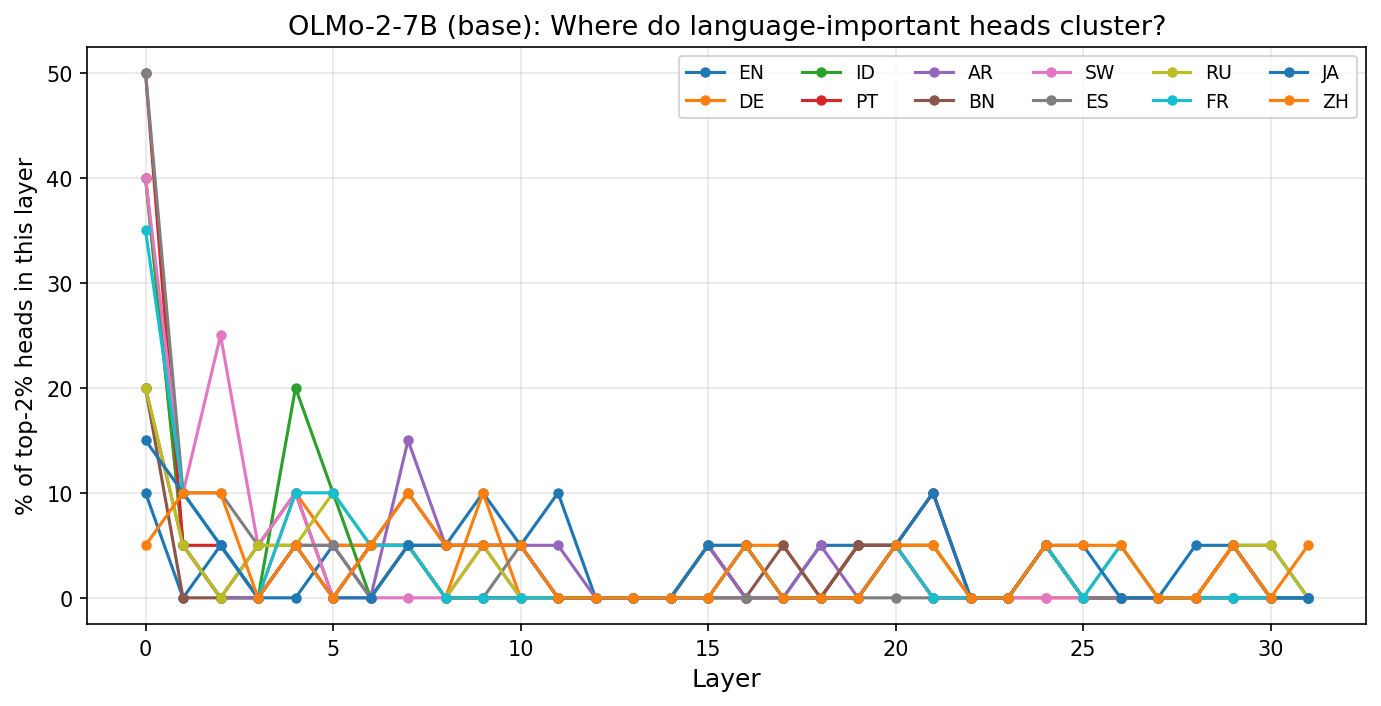

In [12]:
n_top = max(1, int(NUM_LAYERS * NUM_HEADS * TOP_P))

fig, ax = plt.subplots(figsize=(11, 5))

for lang in langs:
    matrix = importance_matrices[lang]
    _, topk_idx = torch.topk(matrix.view(-1), k=n_top)

    layer_counts = torch.zeros(NUM_LAYERS, dtype=torch.int)
    for idx in topk_idx.tolist():
        l, _ = divmod(idx, NUM_HEADS)
        layer_counts[l] += 1

    pct = (layer_counts.float() / layer_counts.sum() * 100).numpy()
    ax.plot(range(NUM_LAYERS), pct, '-o', markersize=4, label=lang.upper())

ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel(f'% of top-{int(TOP_P*100)}% heads in this layer', fontsize=11)
ax.set_title('OLMo-2-7B (base): Where do language-important heads cluster?', fontsize=13)
ax.legend(ncol=6, fontsize=9)
ax.grid(alpha=0.3)

out_path = os.path.join(HEATMAP_DIR, 'head_distribution_base.png')
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.close(fig)
print(f'Saved → {out_path}')
display(Image(out_path))

## 9 · Language-Specific and Language-General Heads
- **Language-general heads:** top-2% for the majority of languages — handle universal grammar/syntax.  
- **Language-specific heads:** top-2% for one language but NOT for most others — the "language gate" we care about.

Saved to `../results/olmo2/head_indices_base.json` and `repeated_indices_base.json`.

In [13]:
from collections import Counter

Q       = 1.0 - TOP_P
MIN_REP = max(2, len(langs) - 1)   # appear in N-1 languages = general

sorted_head_list = []
for lang in langs:
    flat      = importance_matrices[lang].view(-1).float()
    threshold = torch.quantile(flat, q=Q)
    topk_idx  = (flat > threshold).nonzero(as_tuple=False).squeeze()
    if topk_idx.dim() == 0:
        topk_idx = topk_idx.unsqueeze(0)
    vals  = flat[topk_idx]
    order = torch.argsort(vals, descending=True)
    sorted_head_list.append(topk_idx[order])

all_indices  = torch.cat(sorted_head_list).tolist()
index_counts = Counter(all_indices)
general_heads = [
    idx for idx, cnt in sorted(index_counts.items(), key=lambda x: -x[1])
    if cnt >= MIN_REP
]

general_set    = set(general_heads)
specific_heads = {}
for lang, topk in zip(langs, sorted_head_list):
    specific_heads[lang] = [idx for idx in topk.tolist() if idx not in general_set]

with open(os.path.join(RESULTS_DIR, 'head_indices_base.json'), 'w') as f:
    json.dump(specific_heads, f, indent=2)
with open(os.path.join(RESULTS_DIR, 'repeated_indices_base.json'), 'w') as f:
    json.dump(general_heads, f, indent=2)

print(f'Language-general heads (in top-2% for {MIN_REP}+ languages): {len(general_heads)}')
print(f'  First 10 (layer, head): {[(idx // NUM_HEADS, idx % NUM_HEADS) for idx in general_heads[:10]]}')

print(f'\nLanguage-specific heads (top-5 per language):')
for lang in langs:
    top5 = [(idx // NUM_HEADS, idx % NUM_HEADS) for idx in specific_heads[lang][:5]]
    print(f'  {lang.upper():6s}: {len(specific_heads[lang]):3d} heads   top-5: {top5}')

Language-general heads (in top-2% for 11+ languages): 3
  First 10 (layer, head): [(0, 1), (7, 8), (20, 15)]

Language-specific heads (top-5 per language):
  EN    :  18 heads   top-5: [(29, 19), (8, 30), (6, 26), (11, 7), (5, 12)]
  DE    :  18 heads   top-5: [(0, 29), (4, 19), (0, 7), (1, 29), (29, 19)]
  ID    :  18 heads   top-5: [(4, 19), (0, 0), (0, 6), (0, 5), (24, 0)]
  PT    :  18 heads   top-5: [(0, 0), (4, 19), (24, 0), (0, 6), (0, 29)]
  AR    :  18 heads   top-5: [(7, 5), (24, 21), (4, 10), (0, 5), (0, 6)]
  BN    :  18 heads   top-5: [(29, 0), (4, 19), (6, 26), (24, 21), (8, 30)]
  SW    :  19 heads   top-5: [(0, 0), (4, 19), (0, 7), (2, 10), (0, 6)]
  ES    :  19 heads   top-5: [(4, 19), (0, 7), (0, 6), (0, 0), (2, 13)]
  RU    :  18 heads   top-5: [(4, 19), (15, 8), (5, 12), (0, 15), (9, 10)]
  FR    :  18 heads   top-5: [(0, 0), (24, 0), (5, 12), (6, 26), (4, 19)]
  JA    :  18 heads   top-5: [(24, 21), (25, 25), (29, 19), (9, 2), (0, 5)]
  ZH    :  18 heads   top-5: [

## 10 · Specificity Validation — Dark Diagonal
Disable the top-2% heads for each language and measure perplexity across all languages.  
**Expected result:** disabling language X heads hurts language X the most → dark diagonal.

This cell takes a while (it runs the model ~N² times). Use `SPEC_DATA_NUM = 500` for publishable results.

Loading cached results from ../results/olmo2/specificity_base.json
Saved → ../results/olmo2/heatmaps/dark_diagonal_base.png


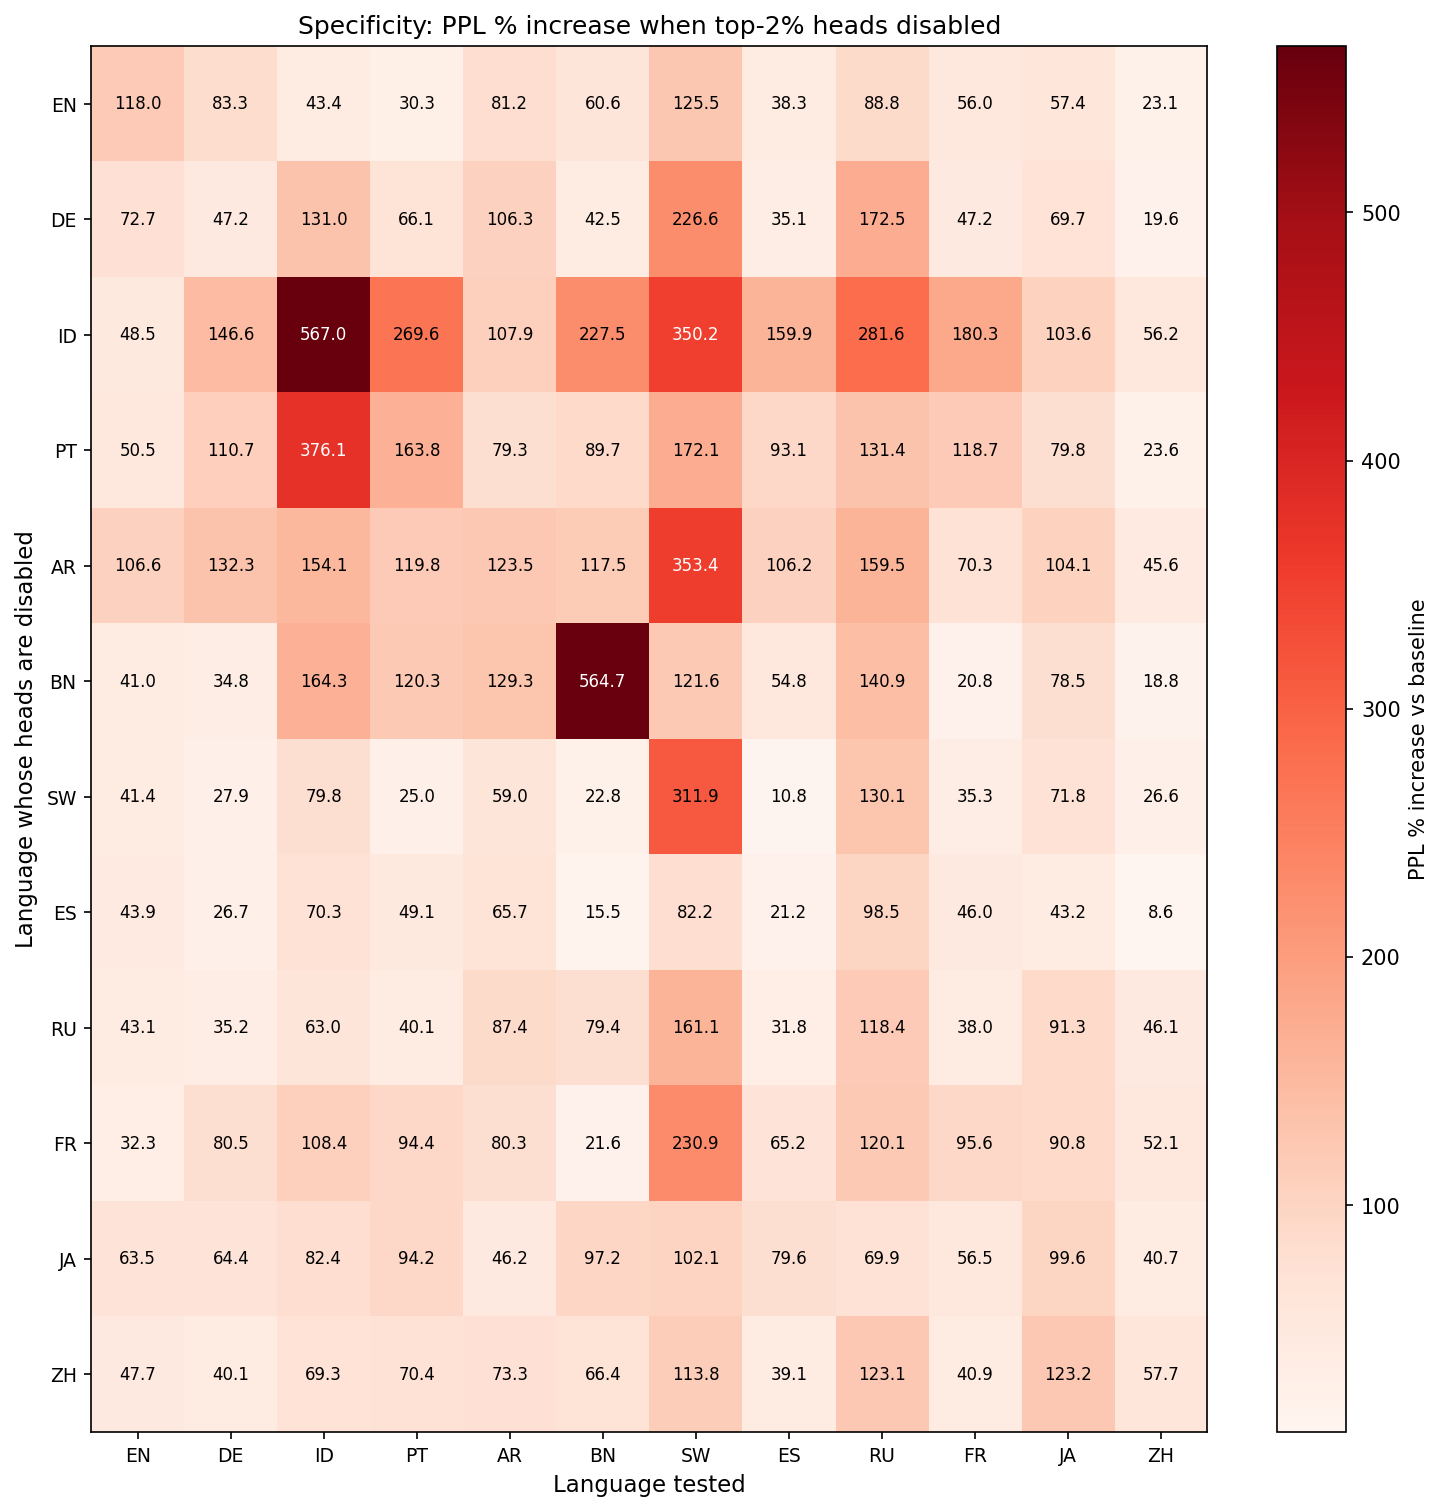

In [14]:
import datasets as hf_datasets

if QUICK_TEST:
    print("QUICK_TEST=True — skipping.")
else:
    def ppl_with_mask(test_lang, head_mask):
        data_file = os.path.join(DATA_DIR, f'ted_{test_lang}.json')
        ds = hf_datasets.load_dataset('json', data_files=data_file, split='train')
        ds = ds.shuffle(seed=37).select(range(min(SPEC_DATA_NUM, len(ds))))
        hm = head_mask.to(model.device).to(model.dtype)
        model_handler.set_lahis_head_mask(model, hm)
        total, count = 0.0, 0
        for item in ds:
            ids = tokenizer(item['text'], return_tensors='pt',
                            truncation=True, max_length=MAX_LENGTH).input_ids.to(model.device)
            with torch.no_grad():
                out = model(ids, labels=ids)
                total += torch.exp(out.loss).item()
                count += 1
        model_handler.clear_lahis_head_mask(model)
        return round(total / max(count, 1), 2)

    def build_specificity_metrics(baseline, masked, eval_langs):
        delta_abs = {
            hl: {tl: round(masked[hl][tl] - baseline[tl], 2) for tl in eval_langs}
            for hl in eval_langs
        }
        delta_pct = {
            hl: {
                tl: round(100.0 * (masked[hl][tl] - baseline[tl]) / baseline[tl], 2)
                if baseline[tl] else 0.0
                for tl in eval_langs
            }
            for hl in eval_langs
        }
        return delta_abs, delta_pct

    spec_path = os.path.join(RESULTS_DIR, 'specificity_base.json')
    if os.path.exists(spec_path):
        print(f'Loading cached results from {spec_path}')
        with open(spec_path) as f:
            spec_results = json.load(f)
        if 'delta_pct' not in spec_results:
            delta_abs, delta_pct = build_specificity_metrics(spec_results['baseline'], spec_results['masked'], langs)
            spec_results['delta_abs'] = delta_abs
            spec_results['delta_pct'] = delta_pct
            with open(spec_path, 'w') as f:
                json.dump(spec_results, f, indent=2)
            print('Added normalized specificity metrics to cached results.')
    else:
        print('Computing baseline perplexity (no masking)...')
        ori_mask = torch.ones(NUM_LAYERS, NUM_HEADS)
        baseline = {l: ppl_with_mask(l, ori_mask) for l in tqdm_nb(langs, desc='baseline')}
        print('Baseline PPL:', baseline)
        print('\nComputing masked perplexity...')
        masked = {}
        for head_lang in tqdm_nb(langs, desc='head_lang'):
            matrix  = importance_matrices[head_lang]
            n_top_s = max(1, int(NUM_LAYERS * NUM_HEADS * TOP_P))
            _, topk_idx = torch.topk(matrix.view(-1), k=n_top_s)
            hm = torch.ones(NUM_LAYERS, NUM_HEADS)
            hm.view(-1)[topk_idx] = 0.0
            masked[head_lang] = {tl: ppl_with_mask(tl, hm) for tl in langs}
        delta_abs, delta_pct = build_specificity_metrics(baseline, masked, langs)
        spec_results = {
            'baseline': baseline,
            'masked': masked,
            'delta_abs': delta_abs,
            'delta_pct': delta_pct,
        }
        with open(spec_path, 'w') as f:
            json.dump(spec_results, f, indent=2)
        print(f'Saved → {spec_path}')

    if 'delta_abs' not in spec_results and 'delta' in spec_results:
        spec_results['delta_abs'] = spec_results['delta']
    eval_langs = list(spec_results['delta_pct'].keys())
    n_l = len(eval_langs)
    mat = np.array([[spec_results['delta_pct'][hl][tl] for tl in eval_langs] for hl in eval_langs])
    fig, ax = plt.subplots(figsize=(max(6, n_l), max(5, n_l)))
    im = ax.imshow(mat, cmap='Reds', aspect='auto')
    ax.set_xticks(range(n_l)); ax.set_xticklabels([l.upper() for l in eval_langs], fontsize=9)
    ax.set_yticks(range(n_l)); ax.set_yticklabels([l.upper() for l in eval_langs], fontsize=9)
    ax.set_xlabel('Language tested', fontsize=11)
    ax.set_ylabel('Language whose heads are disabled', fontsize=11)
    ax.set_title('Specificity: PPL % increase when top-2% heads disabled', fontsize=12)
    for i in range(n_l):
        for j in range(n_l):
            colour = 'white' if mat[i, j] > mat.max() * 0.6 else 'black'
            ax.text(j, i, f'{mat[i,j]:.1f}', ha='center', va='center', fontsize=8, color=colour)
    fig.colorbar(im, ax=ax, label='PPL % increase vs baseline')
    out_path = os.path.join(HEATMAP_DIR, 'dark_diagonal_base.png')
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f'Saved → {out_path}')
    display(Image(out_path))


In [19]:
if os.path.exists('head_indices_finetuned.json'):
    print("Loading from cache...")
    with open('head_indices_finetuned.json') as f:
        ft_specific_heads = json.load(f)
else:
    print("Computing... (this takes a while)")
    with open('head_indices_finetuned.json', 'w') as f:
        json.dump(ft_specific_heads, f, indent=2)


Computing... (this takes a while)


---
## 11 · Base vs Finetuned Comparison

1. Set `FINETUNED_HF_PATH` to his model path (e.g. `"hf:jonny-username/olmo2-finetuned-parallel"`)
2. Run this cell

The delta heatmap (`finetuned − base`) shows which heads were strengthened by LoRA.  
If language-specific heads for the finetuned language X become brighter, that is mechanistic evidence for our gating hypothesis.

config.json:   0%|          | 0.00/680 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/340 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Load model in torch.bfloat16


model.safetensors:   0%|          | 0.00/14.6G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/355 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Applying LAHIS head-mask patch to OLMo-2 attention layers...
  Patch applied.
** Memory allocated by model: 13.59 GB

Loaded: hf:jonny-vr/olmo-2-7B.wikifact-sft-consistent
[en] loading cached
[de] loading cached
[id] loading cached
[pt] loading cached
[ar] loading cached
[bn] loading cached
[sw] loading cached
[es] loading cached
[ru] loading cached
[fr] loading cached
[ja] loading cached
[zh] loading cached
Matrices done.
Saved → ../results/olmo2_finetuned/heatmaps/all_languages_finetuned.png


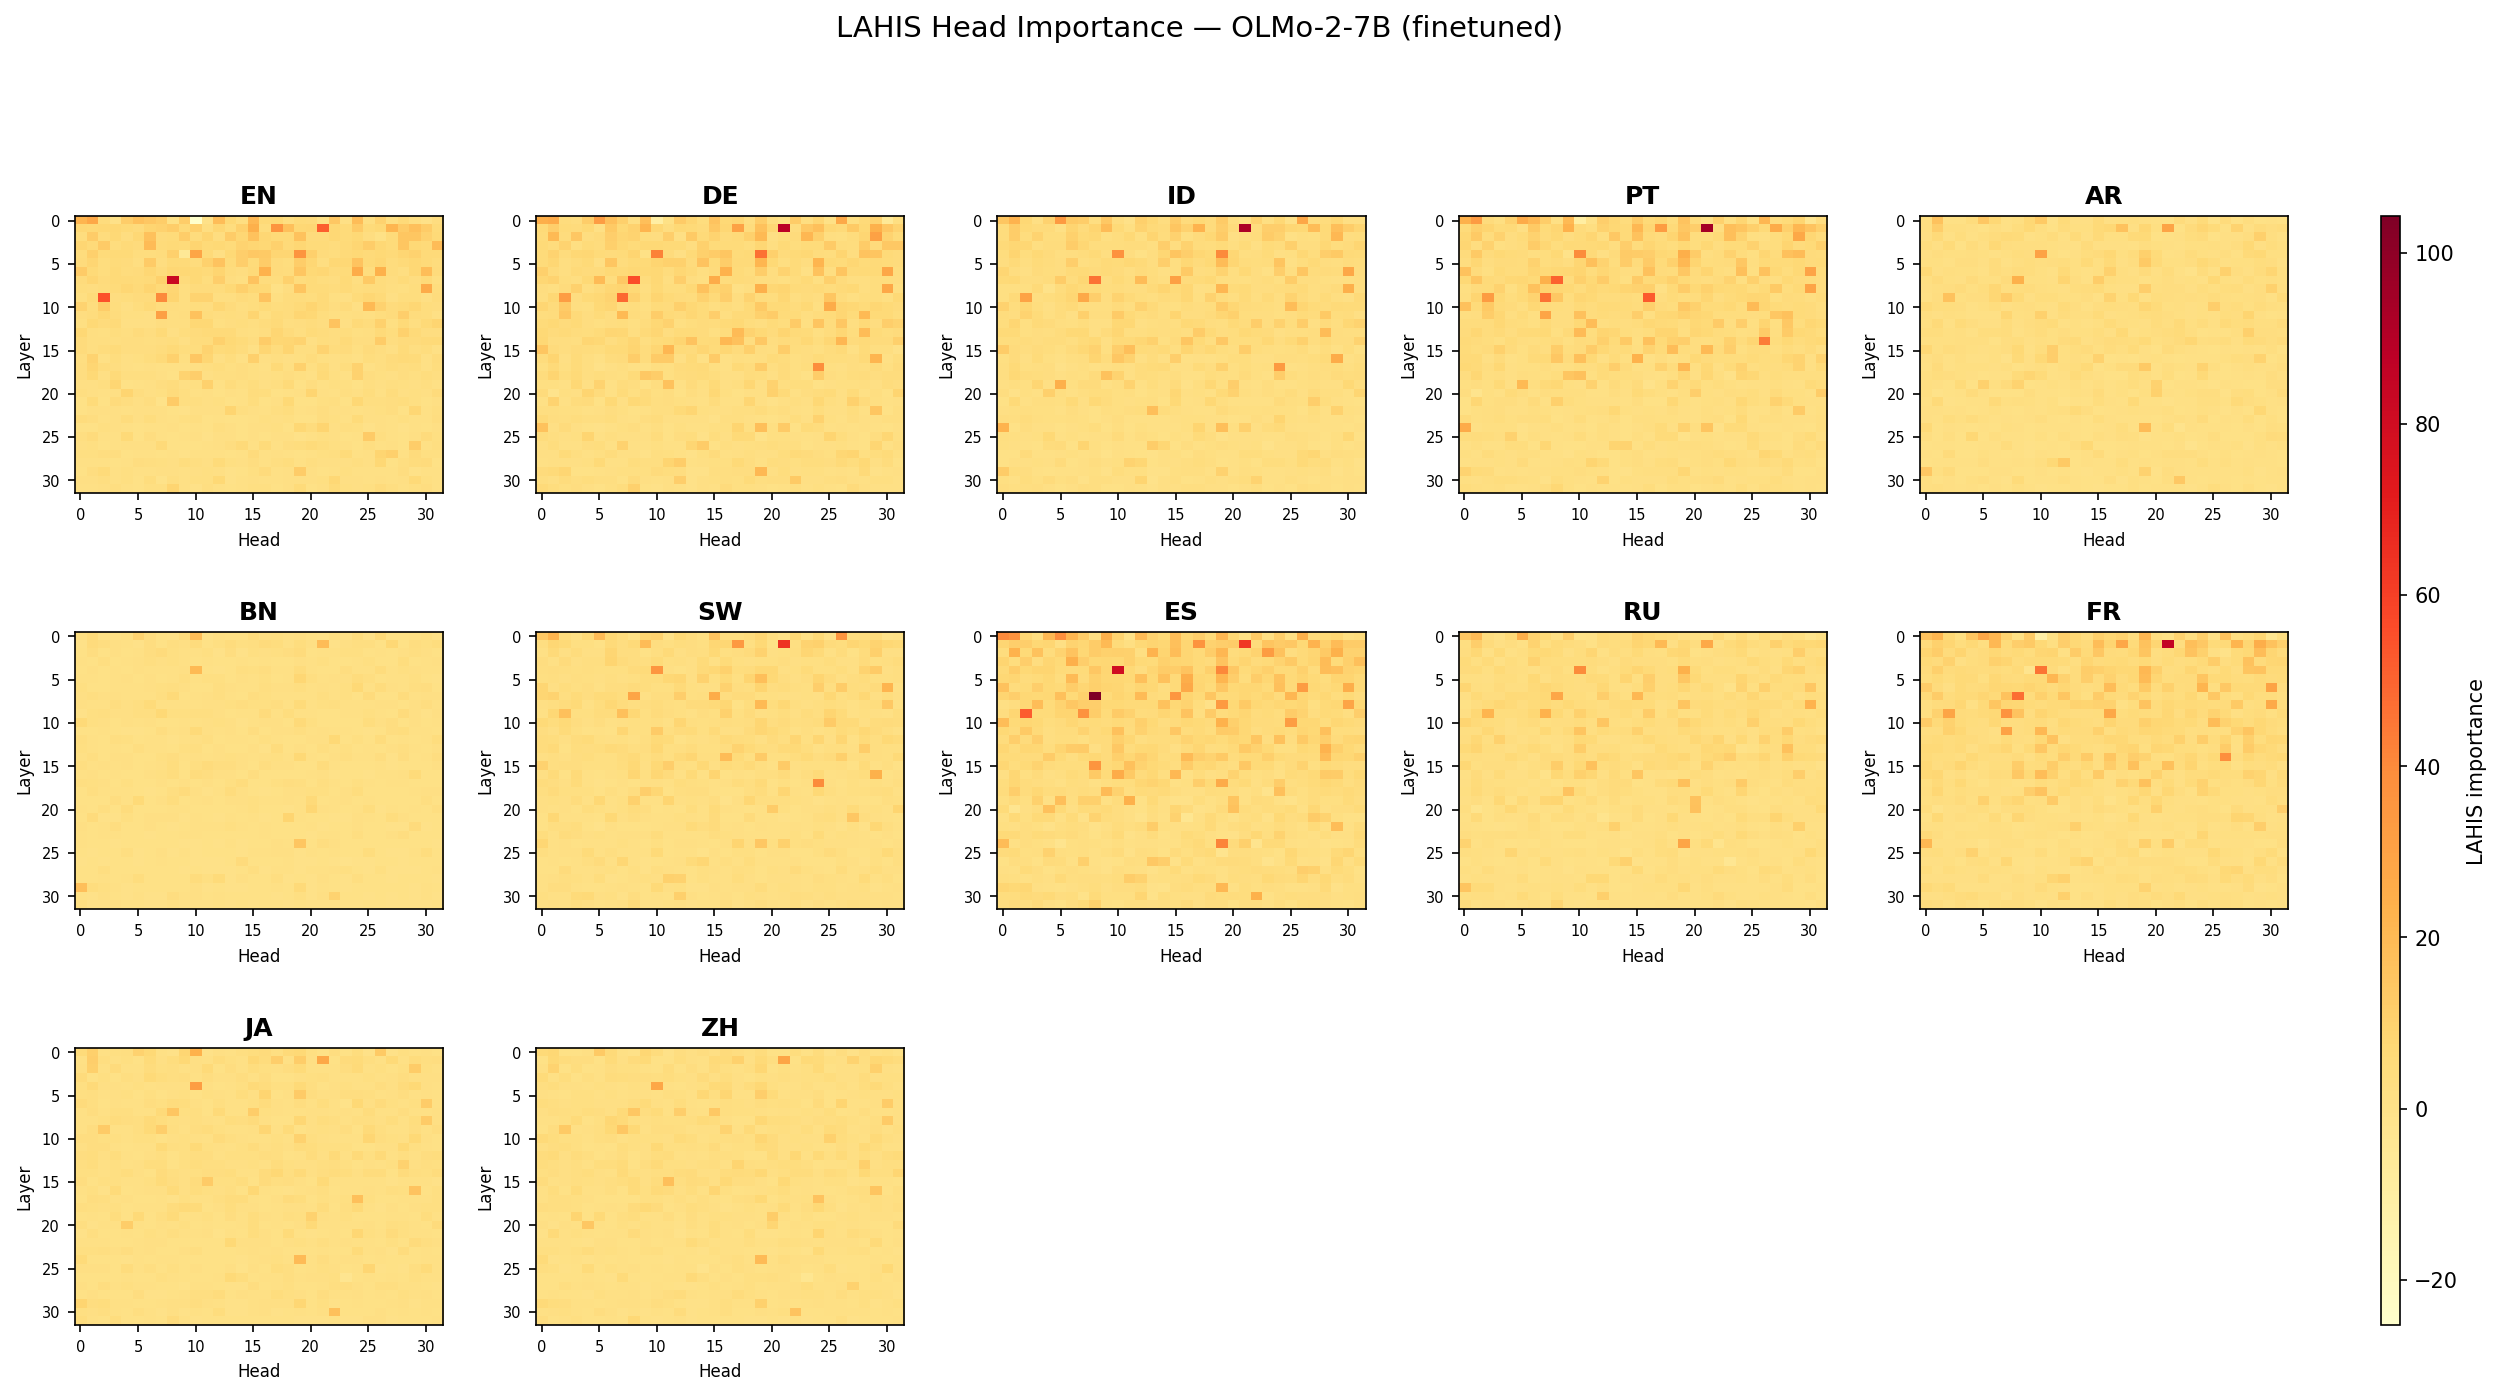

Saved → ../results/olmo2_finetuned/heatmaps/head_distribution_finetuned.png


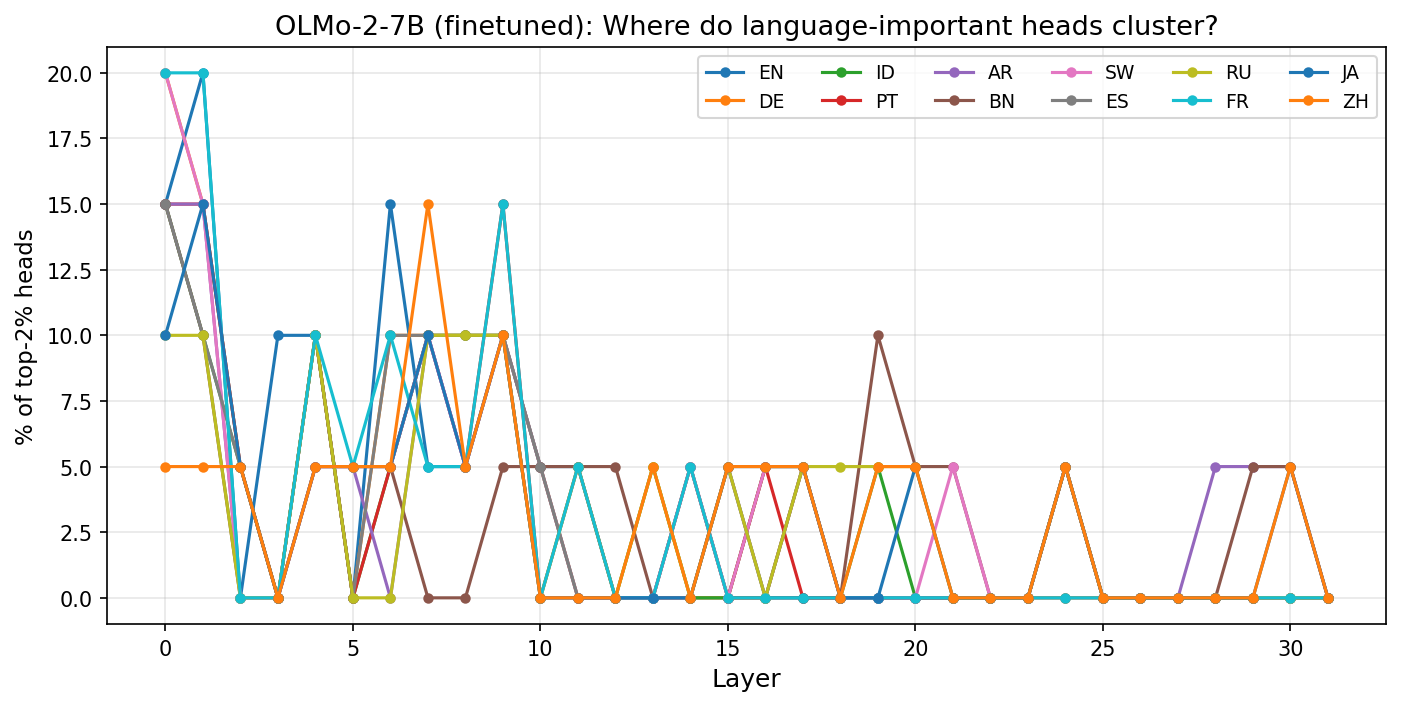


General heads (finetuned): 6  vs base: 3
Specific heads top-5 per language:
  EN    :  15 heads   top-5: [(4, 19), (11, 7), (0, 1), (8, 30), (6, 24)]
  DE    :  15 heads   top-5: [(4, 19), (17, 24), (0, 5), (2, 29), (6, 30)]
  ID    :  15 heads   top-5: [(4, 19), (0, 5), (17, 24), (7, 15), (0, 26)]
  PT    :  15 heads   top-5: [(9, 16), (14, 26), (0, 1), (8, 30), (6, 30)]
  AR    :  15 heads   top-5: [(24, 19), (0, 1), (29, 0), (0, 5), (30, 22)]
  BN    :  18 heads   top-5: [(0, 10), (29, 0), (24, 19), (30, 22), (0, 5)]
  SW    :  15 heads   top-5: [(17, 24), (0, 26), (7, 15), (16, 29), (6, 30)]
  ES    :  15 heads   top-5: [(24, 19), (4, 19), (0, 0), (0, 5), (0, 1)]
  RU    :  15 heads   top-5: [(24, 19), (0, 5), (4, 19), (8, 30), (7, 15)]
  FR    :  15 heads   top-5: [(14, 26), (11, 7), (6, 30), (0, 5), (9, 16)]
  JA    :  15 heads   top-5: [(0, 10), (24, 19), (17, 24), (30, 22), (16, 29)]
  ZH    :  15 heads   top-5: [(24, 19), (15, 11), (17, 24), (30, 22), (16, 29)]
Saved → ../res

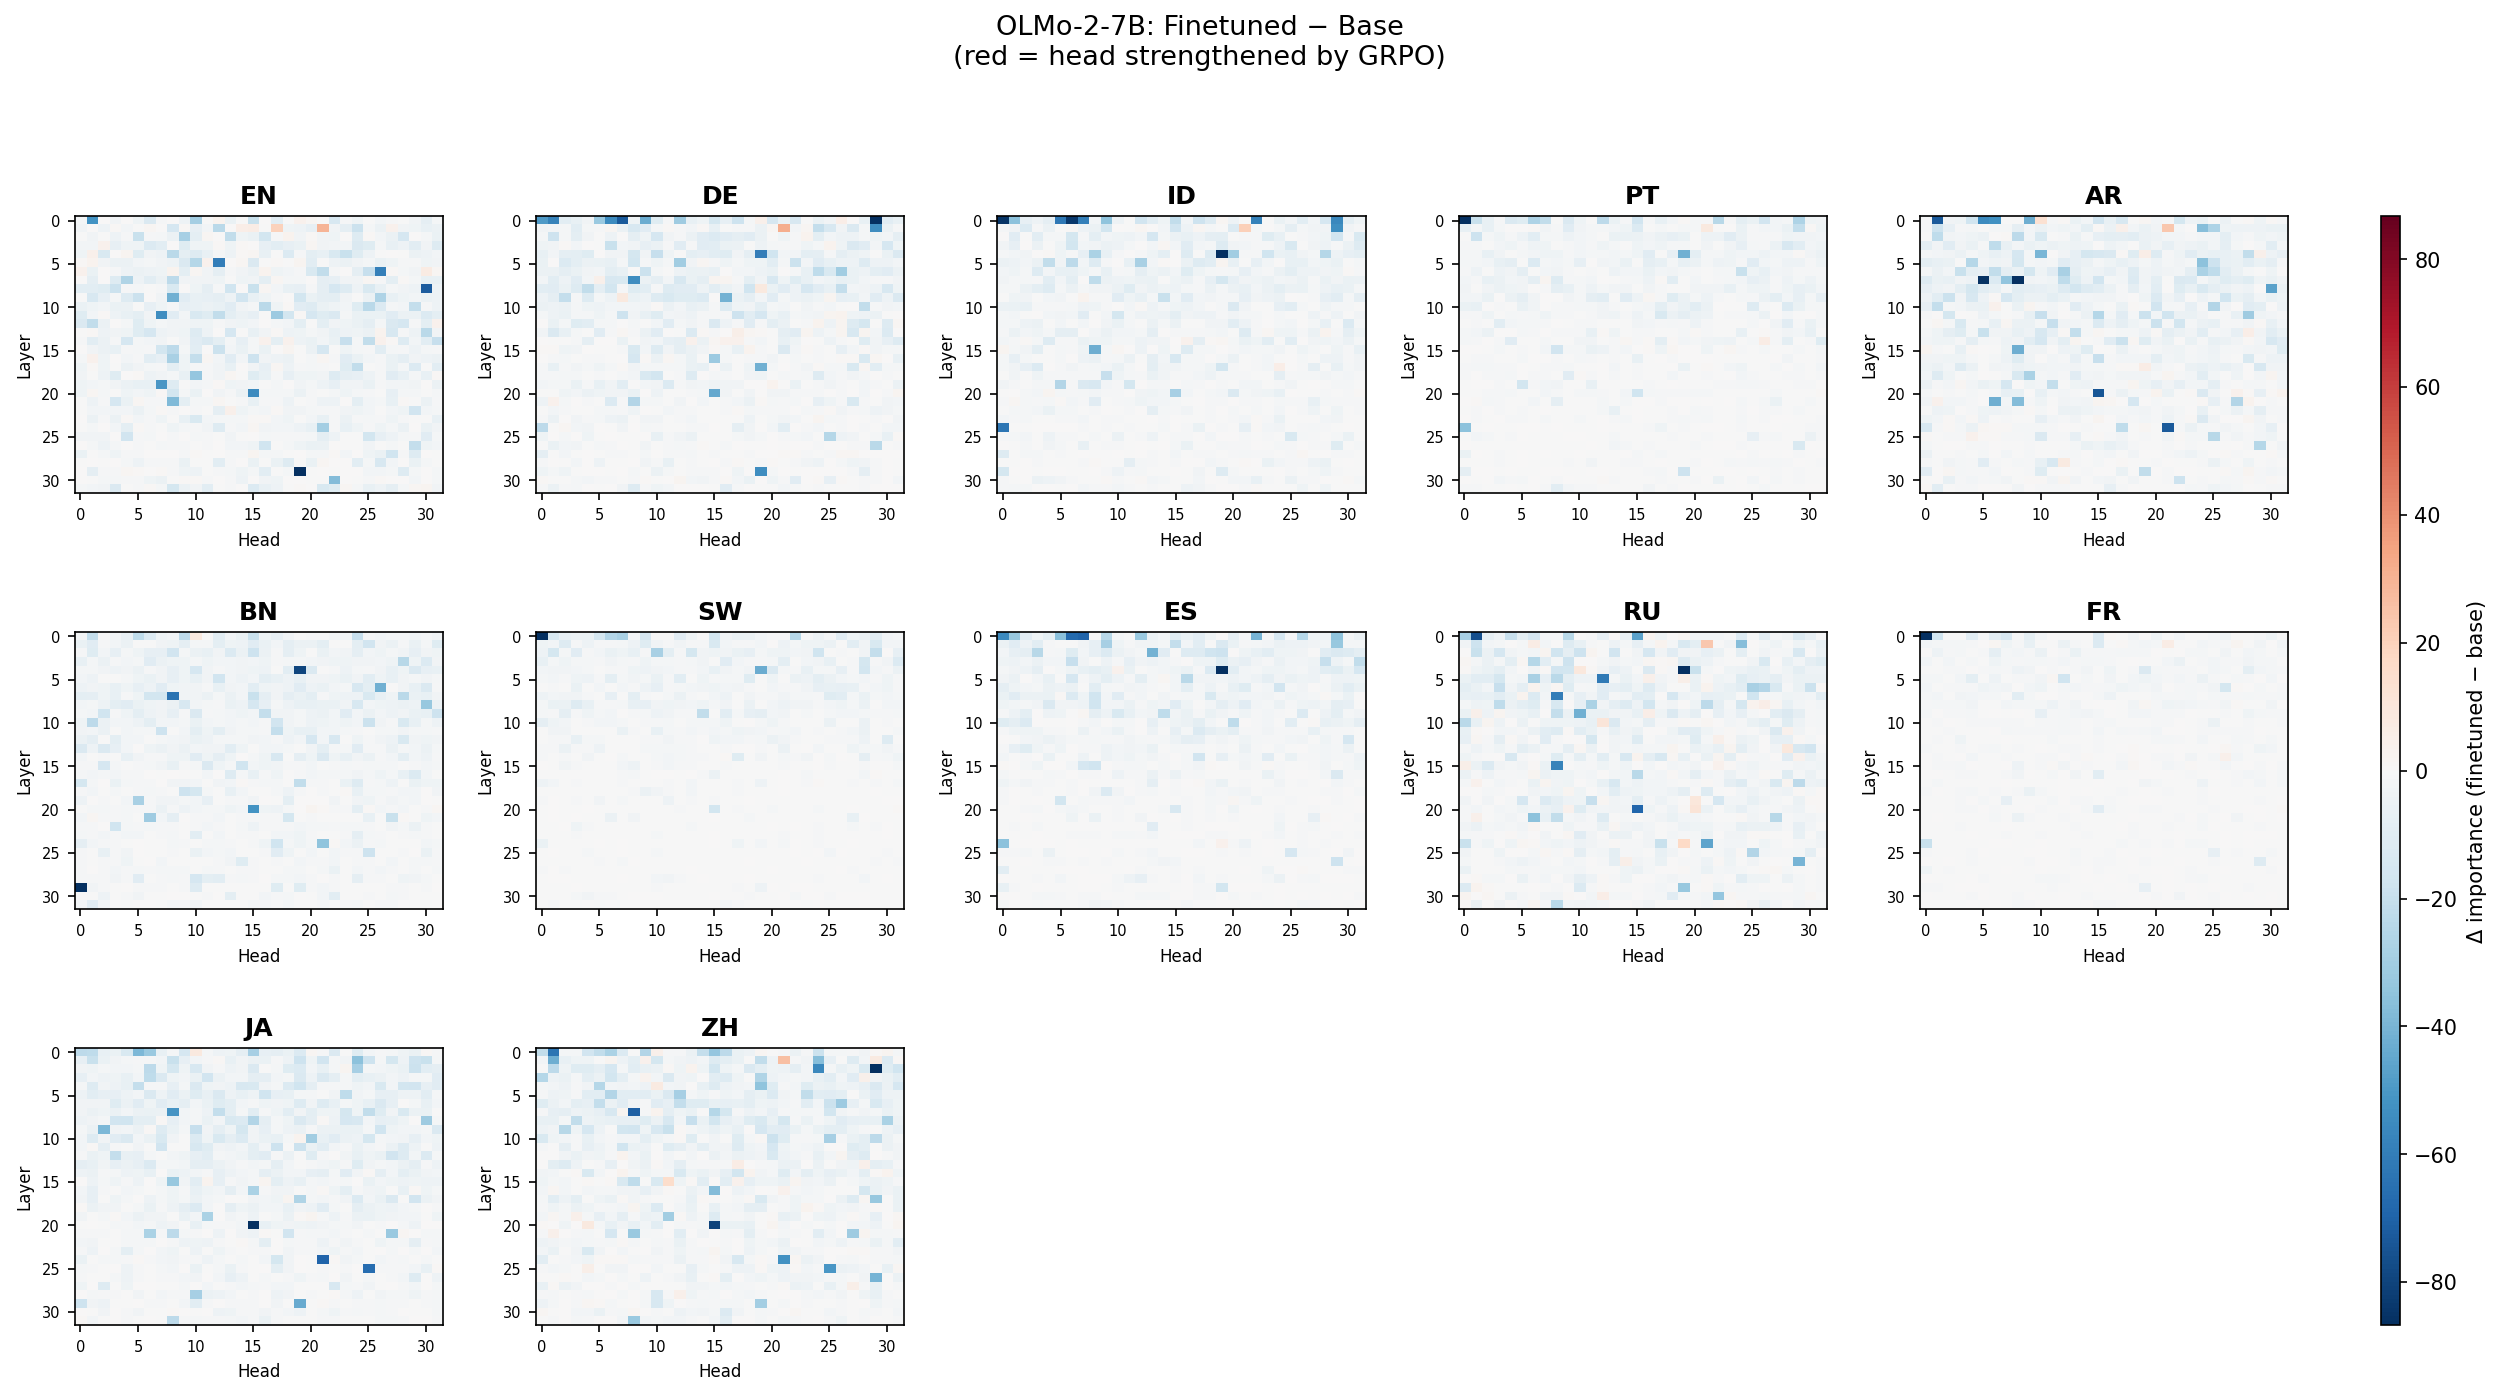

In [15]:
# PUT YOUR MODEL PATH HERE once it's on HuggingFace
FINETUNED_HF_PATH = "hf:jonny-vr/olmo-2-7B.wikifact-sft-consistent"

FT_RESULTS_DIR = '../results/olmo2_finetuned'
FT_HEATMAP_DIR = '../results/olmo2_finetuned/heatmaps'

if FINETUNED_HF_PATH is None:
    print("Set FINETUNED_HF_PATH above and re-run this cell.")
else:
    os.makedirs(FT_RESULTS_DIR, exist_ok=True)
    os.makedirs(FT_HEATMAP_DIR, exist_ok=True)

    # 1. free base model memory then load finetuned
    del model, tokenizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        torch.mps.empty_cache()

    ft_model, ft_tokenizer = model_handler.load_model(
        FINETUNED_HF_PATH, device=DEVICE, half_precision=True, local=False
    )
    ft_model.eval()
    print(f'Loaded: {FINETUNED_HF_PATH}')

    # 2. compute importance matrices
    ft_matrices = {}
    for lang in langs:
        out_path = os.path.join(FT_RESULTS_DIR, f'olmo2_ft_{lang}.pth')
        if os.path.exists(out_path):
            print(f'[{lang}] loading cached')
            ft_matrices[lang] = torch.load(out_path, map_location='cpu').float()
        else:
            print(f'[{lang}] computing...')
            matrix = get_attn_head_matrix_ted(
                ft_model, ft_tokenizer, lan=lang, model_name='olmo2_ft',
                data_dir=DATA_DIR, data_num=DATA_NUM, max_length=MAX_LENGTH,
            )
            ft_matrices[lang] = matrix.float()
            torch.save(matrix, out_path)
    print('Matrices done.')

    # 3. heatmaps (finetuned)
    ft_langs = list(ft_matrices.keys())
    n = len(ft_langs); ncols = min(n, 5); nrows = (n + ncols - 1) // ncols
    all_vals = torch.cat([ft_matrices[l].view(-1) for l in ft_langs])
    vmin, vmax = all_vals.min().item(), all_vals.max().item()
    fig = plt.figure(figsize=(ncols * 4, nrows * 3.2))
    gs  = gridspec.GridSpec(nrows, ncols + 1, width_ratios=[1]*ncols + [0.05], hspace=0.5, wspace=0.3)
    last_im = None
    for i, lang in enumerate(ft_langs):
        row, col = divmod(i, ncols)
        ax = fig.add_subplot(gs[row, col])
        last_im = ax.imshow(ft_matrices[lang].numpy(), aspect='auto', cmap='YlOrRd',
                            vmin=vmin, vmax=vmax, origin='upper')
        ax.set_title(lang.upper(), fontsize=12, fontweight='bold')
        ax.set_xlabel('Head', fontsize=8); ax.set_ylabel('Layer', fontsize=8)
        ax.tick_params(labelsize=7)
    fig.colorbar(last_im, cax=fig.add_subplot(gs[:, ncols]), label='LAHIS importance')
    fig.suptitle('LAHIS Head Importance — OLMo-2-7B (finetuned)', fontsize=14, y=1.02)
    p = os.path.join(FT_HEATMAP_DIR, 'all_languages_finetuned.png')
    fig.savefig(p, dpi=150, bbox_inches='tight'); plt.close(fig)
    print(f'Saved → {p}'); display(Image(p))

    # 4. head distribution by layer (finetuned)
    fig, ax = plt.subplots(figsize=(11, 5))
    for lang in ft_langs:
        _, topk_idx = torch.topk(ft_matrices[lang].view(-1), k=max(1, int(NUM_LAYERS * NUM_HEADS * TOP_P)))
        layer_counts = torch.zeros(NUM_LAYERS, dtype=torch.int)
        for idx in topk_idx.tolist():
            l, _ = divmod(idx, NUM_HEADS)
            layer_counts[l] += 1
        pct = (layer_counts.float() / layer_counts.sum() * 100).numpy()
        ax.plot(range(NUM_LAYERS), pct, '-o', markersize=4, label=lang.upper())
    ax.set_xlabel('Layer', fontsize=12)
    ax.set_ylabel(f'% of top-{int(TOP_P*100)}% heads', fontsize=11)
    ax.set_title('OLMo-2-7B (finetuned): Where do language-important heads cluster?', fontsize=13)
    ax.legend(ncol=6, fontsize=9); ax.grid(alpha=0.3)
    p = os.path.join(FT_HEATMAP_DIR, 'head_distribution_finetuned.png')
    fig.savefig(p, dpi=150, bbox_inches='tight'); plt.close(fig)
    print(f'Saved → {p}'); display(Image(p))

    # 5. head selection (finetuned)
    from collections import Counter
    ft_sorted_head_list = []
    for lang in ft_langs:
        flat = ft_matrices[lang].view(-1).float()
        threshold = torch.quantile(flat, q=1.0 - TOP_P)
        topk_idx = (flat > threshold).nonzero(as_tuple=False).squeeze()
        if topk_idx.dim() == 0: topk_idx = topk_idx.unsqueeze(0)
        ft_sorted_head_list.append(topk_idx[torch.argsort(flat[topk_idx], descending=True)])

    ft_index_counts = Counter(torch.cat(ft_sorted_head_list).tolist())
    ft_general_heads = [idx for idx, cnt in sorted(ft_index_counts.items(), key=lambda x: -x[1])
                        if cnt >= max(2, len(ft_langs) - 1)]
    ft_general_set = set(ft_general_heads)
    ft_specific_heads = {lang: [idx for idx in topk.tolist() if idx not in ft_general_set]
                         for lang, topk in zip(ft_langs, ft_sorted_head_list)}

    with open(os.path.join(FT_RESULTS_DIR, 'head_indices_finetuned.json'), 'w') as f:
        json.dump(ft_specific_heads, f, indent=2)
    with open(os.path.join(FT_RESULTS_DIR, 'repeated_indices_finetuned.json'), 'w') as f:
        json.dump(ft_general_heads, f, indent=2)

    print(f'\nGeneral heads (finetuned): {len(ft_general_heads)}  vs base: {len(general_heads)}')
    print('Specific heads top-5 per language:')
    for lang in ft_langs:
        top5 = [(idx // NUM_HEADS, idx % NUM_HEADS) for idx in ft_specific_heads[lang][:5]]
        print(f'  {lang.upper():6s}: {len(ft_specific_heads[lang]):3d} heads   top-5: {top5}')

    # 6. delta heatmap: finetuned − base (the main paper figure)
    delta_langs = [l for l in langs if l in ft_matrices and l in importance_matrices]
    n = len(delta_langs); ncols = min(n, 5); nrows = (n + ncols - 1) // ncols
    fig = plt.figure(figsize=(ncols * 4, nrows * 3.2))
    gs  = gridspec.GridSpec(nrows, ncols + 1, width_ratios=[1]*ncols + [0.05], hspace=0.5, wspace=0.3)
    last_im = None
    for i, lang in enumerate(delta_langs):
        delta_mat = (ft_matrices[lang] - importance_matrices[lang]).numpy()
        row, col  = divmod(i, ncols)
        ax = fig.add_subplot(gs[row, col])
        vabs = max(abs(delta_mat.min()), abs(delta_mat.max()))
        last_im = ax.imshow(delta_mat, aspect='auto', cmap='RdBu_r',
                            vmin=-vabs, vmax=vabs, origin='upper')
        ax.set_title(lang.upper(), fontsize=12, fontweight='bold')
        ax.set_xlabel('Head', fontsize=8); ax.set_ylabel('Layer', fontsize=8)
        ax.tick_params(labelsize=7)
    fig.colorbar(last_im, cax=fig.add_subplot(gs[:, ncols]), label='Δ importance (finetuned − base)')
    fig.suptitle('OLMo-2-7B: Finetuned − Base\n(red = head strengthened by GRPO)', fontsize=13, y=1.02)
    p = os.path.join(FT_HEATMAP_DIR, 'delta_ft_vs_base.png')
    fig.savefig(p, dpi=150, bbox_inches='tight'); plt.close(fig)
    print(f'Saved → {p}'); display(Image(p))

In [16]:
import torch, os

importance_matrices = {}
ft_matrices = {}

results_base = '../results/olmo2'
results_ft = '../results/olmo2_finetuned'

for lang in ['en','de','id','pt','ar','bn','sw','es','ru','fr','ja','zh']:
    base_path = os.path.join(results_base, f'olmo2_{lang}.pth')
    ft_path = os.path.join(results_ft, f'olmo2_ft_{lang}.pth')

    if os.path.exists(base_path):
        importance_matrices[lang] = torch.load(base_path, map_location='cpu')
    if os.path.exists(ft_path):
        ft_matrices[lang] = torch.load(ft_path, map_location='cpu')

print(f'Base: {list(importance_matrices.keys())}')
print(f'FT: {list(ft_matrices.keys())}')


Base: ['en', 'de', 'id', 'pt', 'ar', 'bn', 'sw', 'es', 'ru', 'fr', 'ja', 'zh']
FT: ['en', 'de', 'id', 'pt', 'ar', 'bn', 'sw', 'es', 'ru', 'fr', 'ja', 'zh']


Saved → ../results/olmo2/heatmaps/head_overlap_base_vs_ft.png


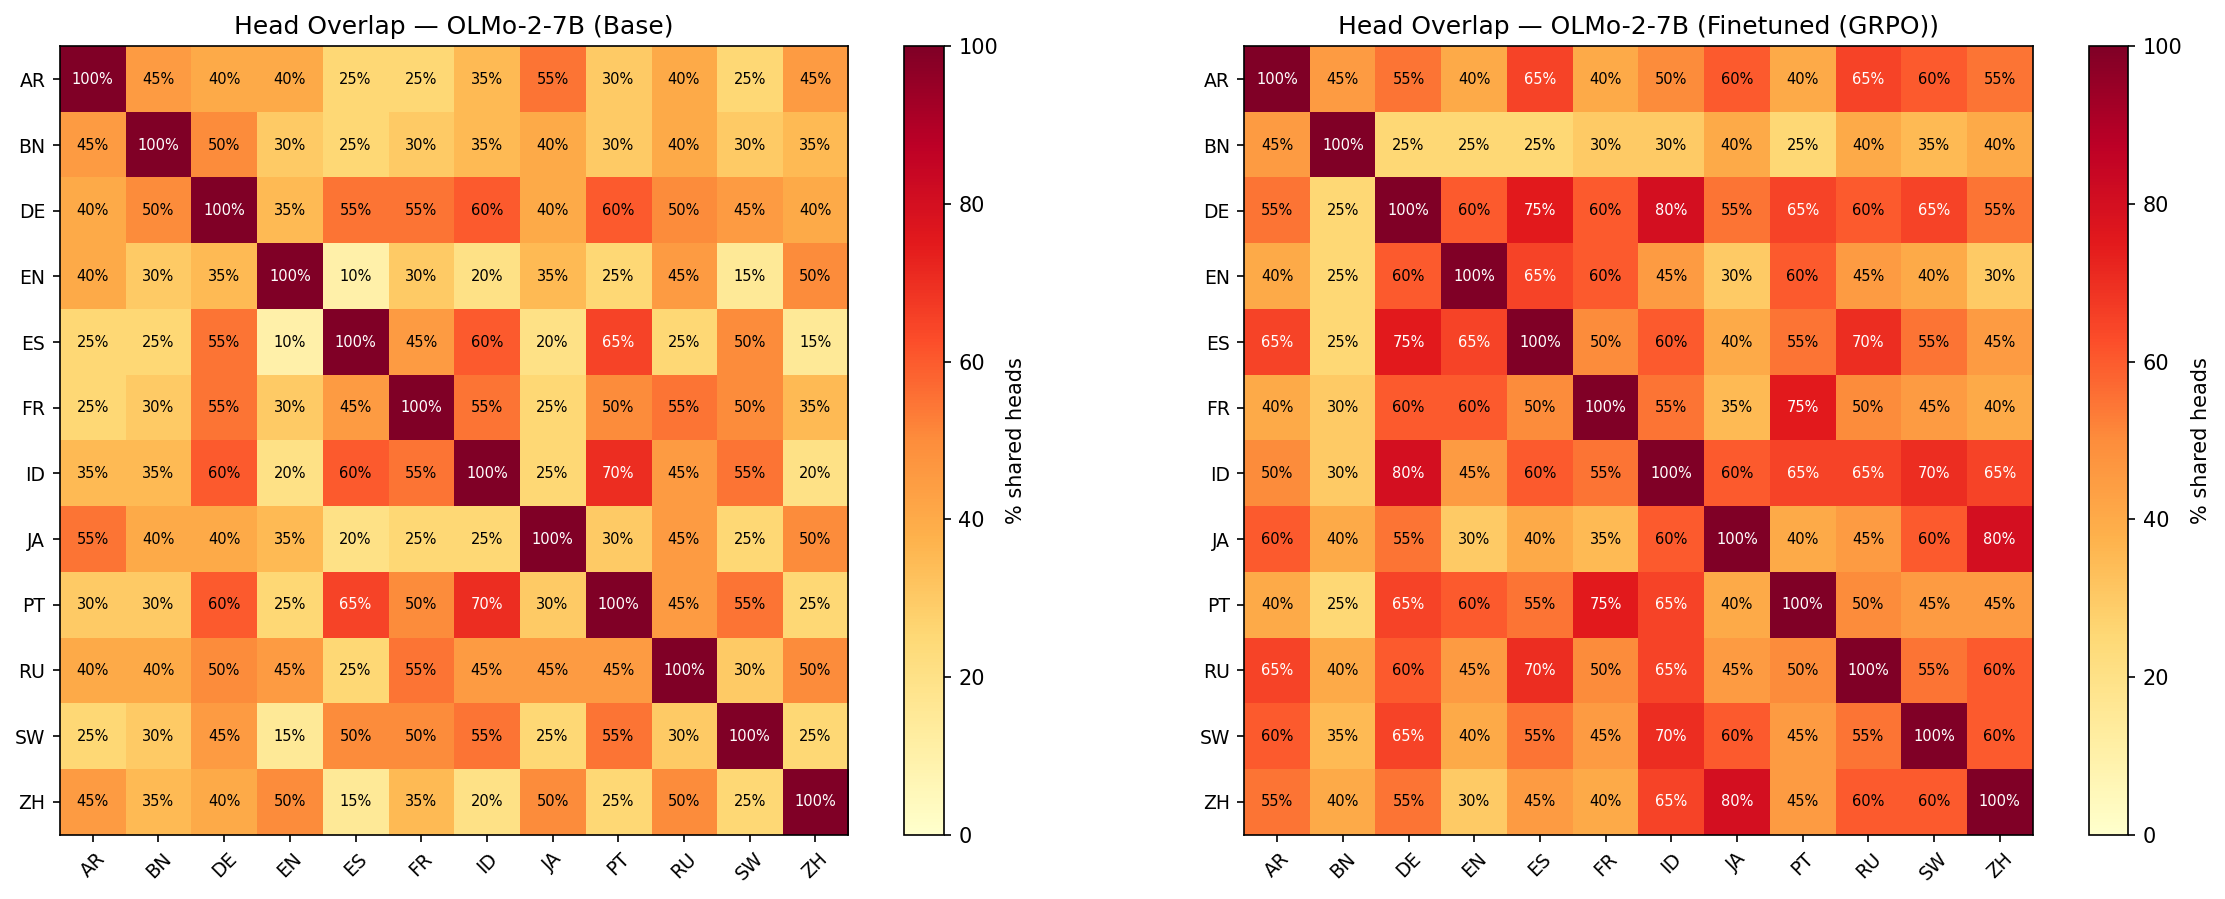

In [17]:
NUM_LAYERS = 32
NUM_HEADS = 32
TOP_P = 0.02

n_top = max(1, int(NUM_LAYERS * NUM_HEADS * TOP_P))

# Get top-2% head indices per language (as sets)
def get_top_heads(matrices):
    top_heads = {}
    for lang, mat in matrices.items():
        _, topk_idx = torch.topk(mat.view(-1), k=n_top)
        top_heads[lang] = set(topk_idx.tolist())
    return top_heads

base_heads = get_top_heads(importance_matrices)
ft_heads   = get_top_heads(ft_matrices)

# Build overlap matrix
def overlap_matrix(heads_dict):
    langs = sorted(heads_dict.keys())
    mat = np.zeros((len(langs), len(langs)))
    for i, l1 in enumerate(langs):
        for j, l2 in enumerate(langs):
            overlap = len(heads_dict[l1] & heads_dict[l2])
            mat[i, j] = overlap / n_top * 100  # % overlap
    return mat, langs

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (mat, langs), title in zip(
    axes,
    [overlap_matrix(base_heads), overlap_matrix(ft_heads)],
    ['Base', 'Finetuned (GRPO)']
):
    im = ax.imshow(mat, cmap='YlOrRd', vmin=0, vmax=100)
    ax.set_xticks(range(len(langs)))
    ax.set_xticklabels([l.upper() for l in langs], fontsize=9, rotation=45)
    ax.set_yticks(range(len(langs)))
    ax.set_yticklabels([l.upper() for l in langs], fontsize=9)
    ax.set_title(f'Head Overlap — OLMo-2-7B ({title})', fontsize=12)
    for i in range(len(langs)):
        for j in range(len(langs)):
            ax.text(j, i, f'{mat[i,j]:.0f}%', ha='center', va='center', fontsize=7,
                    color='white' if mat[i,j] > 60 else 'black')
    fig.colorbar(im, ax=ax, label='% shared heads')

plt.tight_layout()
out_path = os.path.join(HEATMAP_DIR, 'head_overlap_base_vs_ft.png')
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.close(fig)
print(f'Saved → {out_path}')
display(Image(out_path))


Saved → ../results/olmo2/heatmaps/head_stability_base_vs_ft.png


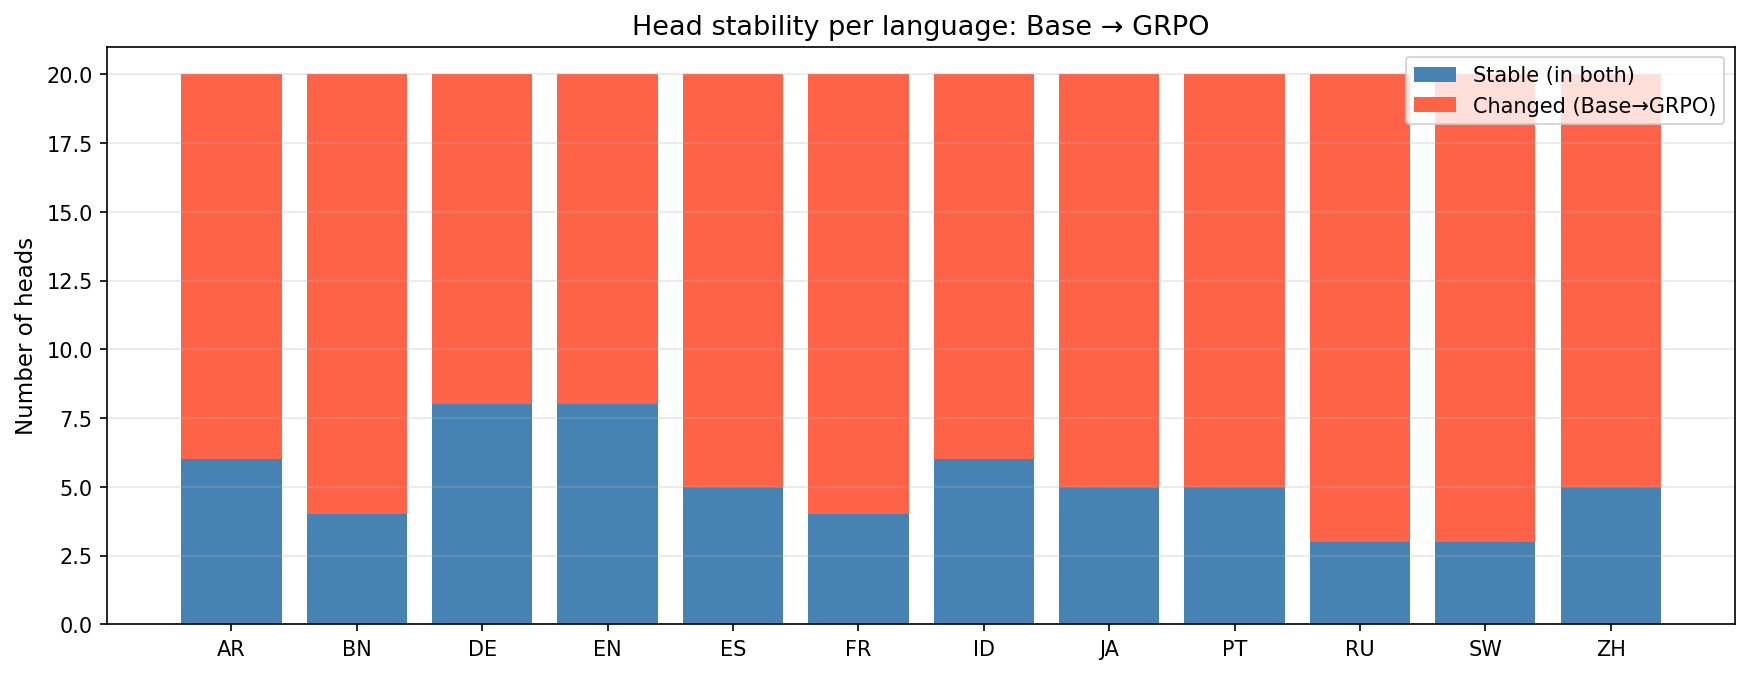

In [18]:
fig, ax = plt.subplots(figsize=(14, 5))

stable = [len(base_heads[l] & ft_heads[l]) for l in langs]
changed = [n_top - s for s, l in zip(stable, langs)]

x = np.arange(len(langs))
ax.bar(x, stable, label='Stable (in both)', color='steelblue')
ax.bar(x, changed, bottom=stable, label='Changed (Base→GRPO)', color='tomato')

ax.set_xticks(x)
ax.set_xticklabels([l.upper() for l in langs], fontsize=10)
ax.set_ylabel('Number of heads', fontsize=11)
ax.set_title('Head stability per language: Base → GRPO', fontsize=13)
ax.legend()
ax.grid(alpha=0.3, axis='y')

out_path = os.path.join(HEATMAP_DIR, 'head_stability_base_vs_ft.png')
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.close(fig)
print(f'Saved → {out_path}')
display(Image(out_path))